In [8]:
import sys
sys.path.append('code')
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [6]:
def z_norm(header: dict, values: np.ndarray) -> np.ndarray:
    """
        Z-normalize signal values using summary statistics from a bigWig header.
    
        Args:
            header: dict with keys "sumData", "sumSquared", "nBasesCovered".
            values: raw signal values to normalize.
    
        Returns:
            Z-normalized values.
    """
    required_keys = {"sumData", "sumSquared", "nBasesCovered"}
    if not required_keys.issubset(header.keys()):
        raise ValueError(f"Header is missing required keys: {required_keys}")
    n = header["nBasesCovered"]
    if n == 0:
        raise ValueError("nBasesCovered is 0; cannot compute mean and standard deviation")
    mean = header["sumData"] / n
    mean_sq = header["sumSquared"] / n
    variance = max(mean_sq - mean**2, 0.0)
    std = np.sqrt(variance)
    if std == 0:
        raise ValueError("Standard deviation is 0; cannot perform Z-normalization")
    return (values - mean) / std

def sigmoid_norm(x,p1=[0.3,0.3],p2=[0.7,0.7]):
    """
        Map values through a logistic curve fitted to two control points.
    
        Args:
            x: raw values.
            p1, p2: anchor points (x, y) defining the curve.
    
        Returns:
            Values mapped to (0, 1).
    """
    x1,y1 = p1;x2,y2 = p2
    k = ( np.log(1/y1-1)-np.log(1/y2-1) ) / ( x2-x1 )
    b = np.log(1/y1-1)+k*x1
    
    x = np.array(x)
    return 1/(1+np.exp(-k*x+b))

def Logistic_norm(x, px=[0, 2.0, 4.0, 6.0], py=[0.0, 0.5, 0.8, 1.0]):
    """
        Map raw values through a monotone PCHIP curve onto a probability-like scale.
    
        Args:
            x: raw values (e.g. RRA scores).
            px, py: control points of the monotone interpolation.
    
        Returns:
            Interpolated values (default range roughly [0, 1]).
    """
    x = np.asarray(x)
    return PchipInterpolator(px, py)(x)

def sliding_average(y, k, mode='valid'):
    """
        Smooth a 1-D signal with a sliding window average (convolution).
    
        Args:
            y: input signal.
            k: window size.
            mode: convolution mode, "valid" by default.
    
        Returns:
            Smoothed signal.
    """
    y = np.asarray(y)
    window = np.ones(k) / k
    smoothed = np.convolve(y, window, mode=mode)
    return smoothed

def draw_transcript(
    ax,gene_df,x_lim=(0, 10000),y_lim=(2.0, 12.0),interval_base=64,intron_linewidth=1.0,gene_font_size=12,arrow_font_size=10,
):
    """
    ax            : matplotlib.axes.Axes
    gene_df       : tidy gene table (columns: gene_name, start, end, strand)
    x_lim         : (start, end), the actual plotting range
    y_lim         : y-axis range, default (2.0, 12.0)
    interval_base : arrow spacing base, default 64
    """

    start, end = x_lim
    y_min, y_max = y_lim

    # ====== y-axis auto-scaling factor ======
    default_y_span = 12.0 - 2.0   # height from the original design
    current_y_span = y_max - y_min
    y_scale = current_y_span / default_y_span

    rect_height = 1.0 * y_scale
    flag_step = 2.0 * y_scale
    text_offset = 1.0 * y_scale

    # ====== initial flag (preserving the original top-down stacking logic) ======
    flag = y_max - 2.0 * y_scale

    interval = (end - start) // interval_base

    # ====== main drawing logic ======
    for gene, group in gene_df.groupby('gene_name', sort=False):
        strand = group.iloc[0]['strand']

        # ---- exon rectangles ----
        for rw in group.itertuples():
            rect = patches.Rectangle(
                (rw.start, flag),
                rw.end - rw.start,
                rect_height,
                edgecolor=None,
                facecolor='#57606f',
                alpha=1.0,
                linewidth=1.5
            )
            ax.add_patch(rect)

        # ---- intron line ----
        ax.plot(
            [group['start'].min(), group['end'].max()],
            [flag + rect_height / 2, flag + rect_height / 2],
            color='b',linewidth=intron_linewidth
        )

        # ---- strand-direction arrows (exactly the original clipping logic) ----
        if strand == '+':
            for x in range(
                min(
                    group['start'].min() + interval,
                    (group['start'].min() + group['end'].max()) // 2
                ),
                group['end'].max(),
                interval
            ):
                if x > min(end, group['end'].max()):
                    continue
                if x < max(start, group['start'].min()):
                    continue
                ax.text(x, flag + rect_height / 2, '>',
                        va='center', ha='center',
                        fontsize=arrow_font_size, color='b')
        else:
            for x in range(
                max(
                    (group['start'].min() + group['end'].max()) // 2,
                    group['end'].max() - interval
                ),
                group['start'].min(),
                -interval
            ):
                if x > min(end, group['end'].max()):
                    continue
                if x < max(start, group['start'].min()):
                    continue
                ax.text(x, flag + rect_height / 2, '<',
                        va='center', ha='center',
                        fontsize=arrow_font_size, color='b')

        # ---- gene-name annotation (logic 100% preserved) ----
        if not (group['end'].max() <= start or group['start'].min() >= end):
            center = (group['start'].min() + group['end'].max()) // 2

            if center < start:
                label_x = (start + group['end'].max()) // 2
            elif center > end:
                label_x = (group['start'].min() + end) // 2
            else:
                label_x = center

            ax.text(
                label_x,
                flag + text_offset,
                gene,
                va='bottom',
                ha='center',
                fontsize=gene_font_size
            )

        # ---- flag decrement & wraparound ----
        flag -= flag_step
        if flag <= y_min:
            flag = y_max - 2.0 * y_scale

    # ====== axis settings ======
    ax.set_xlim(start, end)
    ax.set_ylim(y_min, y_max)

# Figure 5b

/cluster2/huanglab/liquan/temp/Rtemp/ipykernel_119473/876822726.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="LFC",


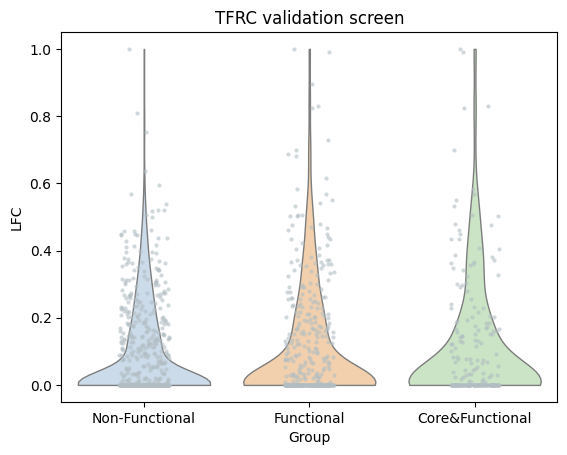

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
FACSresult = pd.read_csv(
    'data/fig5/tfrc_facs_sgrna.txt',
    sep='\t'
)
FACSresult = FACSresult.loc[FACSresult['Gene'].str.contains('AML'), ['sgrna','Gene','LFC']]
lfc = FACSresult['LFC'].values
FACSresult['LFC'] = np.clip(lfc, 0, 999) / lfc.max()
PROresult = pd.read_csv(
    "data/fig5/tfrc_prolif_sgrna.txt",
    sep='\t'
)
PROresult = PROresult.loc[PROresult['Gene'].str.contains('AML'), ['sgrna','Gene','LFC']]
lfc = -1 * PROresult['LFC'].values
PROresult['LFC'] = np.clip(lfc, 0, 999) / lfc.max()
result = pd.concat([FACSresult, PROresult])
pred = pd.read_csv(
    'data/fig5/tfrc_cre_function_score.txt',
    sep='\t'
)
TFRCLIST_MERGE = result.copy()
TFRCLIST_MERGE['group_A'] = 'non-Functional'
TFRCLIST_MERGE.loc[TFRCLIST_MERGE['Gene'].isin(pred.loc[pred['group'].isin(['Core-Functional','Functional']), 'id']), 'group_A'] = 'Functional'
TFRCLIST_MERGE['group_B'] = 'non-Functional'
TFRCLIST_MERGE.loc[TFRCLIST_MERGE['Gene'].isin(pred.loc[pred['group']=='Core-Functional', 'id']), 'group_B'] = 'Core&Functional'
TFRCLIST_MERGE.loc[TFRCLIST_MERGE['Gene'].isin(pred.loc[pred['group']=='Functional', 'id']), 'group_B'] = 'Functional'
NF_A = TFRCLIST_MERGE.loc[TFRCLIST_MERGE['group_A']=='non-Functional', 'LFC']
F_A  = TFRCLIST_MERGE.loc[TFRCLIST_MERGE['group_A']=='Functional', 'LFC']
CF_B = TFRCLIST_MERGE.loc[TFRCLIST_MERGE['group_B']=='Core&Functional', 'LFC']
plot_df = pd.DataFrame({
    "LFC": np.concatenate([NF_A.values, F_A.values, CF_B.values]),
    "Group": (["Non-Functional"] * len(NF_A) +
              ["Functional"] * len(F_A) +
              ["Core&Functional"] * len(CF_B))
})
order = ["Non-Functional", "Functional", "Core&Functional"]
sns.violinplot(data=plot_df, x="Group", y="LFC",
               order=order, palette=["#c6dbef", "#fdd0a2", "#c7e9c0"],
               cut=0, inner=None, linewidth=1)
sns.stripplot(data=plot_df, x="Group", y="LFC",
              order=order, color="#b2bec3", size=3, alpha=0.6, jitter=0.15)
plt.title('TFRC validation screen')
plt.ylabel('LFC')
plt.show()

# Figure 5c

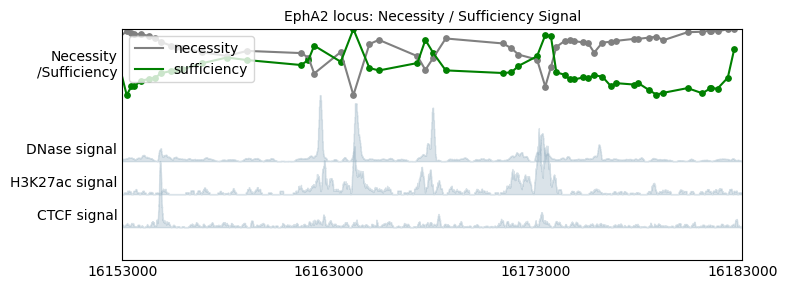

In [10]:
import pickle
with open('data/fig5/ephA2_preprocessed.pkl', 'rb') as f:
    prep = pickle.load(f)
Epah2table = prep['Epah2table']
data = prep['data']
start = 16153000; end = 16183000
dnase_array = np.load('data/fig5/epi_DNase_chr1_16153000_16183000.npy')
k27ac_array = np.load('data/fig5/epi_H3K27ac_chr1_16153000_16183000.npy')
ctcf_array  = np.load('data/fig5/epi_CTCF_chr1_16153000_16183000.npy')
fig = plt.figure(figsize=(8, 3))
positions = [i for i in range(start, end)]
plt.scatter(data['start'], data['necessity'], color='grey', s=15)
plt.scatter(data['start'], data['sufficient'], color='green', s=15)
plt.plot(data['start'], data['necessity'], color='grey', label='necessity')
plt.plot(data['start'], data['sufficient'], color='green', label='sufficiency')
plt.fill_between(positions, -1.0, dnase_array/dnase_array.max() - 1.0, color='#95afc0', alpha=0.35)
plt.fill_between(positions, -1.5, k27ac_array/k27ac_array.max() - 1.5, color='#95afc0', alpha=0.35)
plt.fill_between(positions, -2.0, ctcf_array/ctcf_array.max() - 2.0, color='#95afc0', alpha=0.35)
plt.xlim([start, end])
plt.ylim([-2.5, 1.0])
ax = plt.gca()
ax.tick_params(axis='both', which='both', length=0)
plt.xticks([16153000, 16163000, 16173000, 16183000],
           ['16153000', '16163000', '16173000', '16183000'])
plt.yticks([-1.8, -1.3, -0.8, 0.5],
           ['CTCF signal', 'H3K27ac signal', 'DNase signal',
            'Necessity\n/Sufficiency'])
plt.title('EphA2 locus: Necessity / Sufficiency Signal', fontsize=10)
plt.legend(loc='upper left')
plt.savefig('figures/Fig5c_EphA2.png', dpi=300, bbox_inches='tight')
plt.show()


# Figure 5e

High vs Rest: odds ratio = 1.8405, p-value = 1.8892e-91
Mann-Whitney U test: statistic = 191945817.5000, p-value = 5.2575e-28


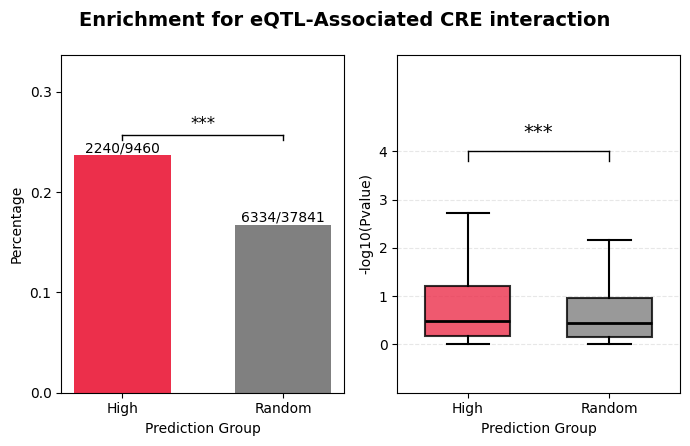

In [11]:
import pandas as pd
import pickle
import numpy as np
from scipy.stats import fisher_exact, mannwhitneyu
import matplotlib.pyplot as plt
lll = pd.read_csv(
    'data/fig5/lilei_interaction_list.txt',
    sep='\t', index_col=0
)
with open('data/fig5/lilei_results.pkl', 'rb') as file:
    result = pickle.load(file)
ipscore = []
for r in result:
    ipscore.append((r[0] - r[1]).sum())
lll['ipscore'] = ipscore
lll['Beta_norm'] = lll.apply(lambda x: abs(x['Beta']) if x['Pvalue'] < 0.01 else 0, axis=1)
high = lll.loc[lll['ipscore'] > np.quantile(lll['ipscore'], 0.75)]
total = lll
rest = total.drop(high.index)
table = [
    [high['label'].sum(), len(high) - high['label'].sum()],
    [rest['label'].sum(), len(rest) - rest['label'].sum()]
]
oddsratio, p_value = fisher_exact(table, alternative='greater')
print(f"High vs Rest: odds ratio = {oddsratio:.4f}, p-value = {p_value:.4e}")
high_acc = high['label'].sum() / len(high)
total_acc = total['label'].sum() / len(total)
high_copy = high.copy()
high_copy['Group'] = 'High'
total_copy = total.copy()
total_copy['Group'] = 'Random'
plot_data = pd.concat([high_copy[['Pvalue', 'Group']], total_copy[['Pvalue', 'Group']]], axis=0)
plot_data['-log10(Pvalue)'] = -np.log10(plot_data['Pvalue'])
high_values = plot_data[plot_data['Group'] == 'High']['-log10(Pvalue)'].values
random_values = plot_data[plot_data['Group'] == 'Random']['-log10(Pvalue)'].values
stat, p_val_mw = mannwhitneyu(high_values, random_values, alternative='greater')
print(f"Mann-Whitney U test: statistic = {stat:.4f}, p-value = {p_val_mw:.4e}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4.5))
bars = ax1.bar([0, 1], [high_acc, total_acc],
               color=['#ec2F4B', '#808080'], width=0.6)
ax1.text(x=0, y=high_acc, s=f"{high['label'].sum()}/{len(high)}",
         ha='center', va='bottom', fontsize=10)
ax1.text(x=1, y=total_acc, s=f"{total['label'].sum()}/{len(total)}",
         ha='center', va='bottom', fontsize=10)
if p_value < 0.001:
    sig_symbol = '***'
elif p_value < 0.01:
    sig_symbol = '**'
elif p_value < 0.05:
    sig_symbol = '*'
else:
    sig_symbol = 'ns'
y_line = max(high_acc, total_acc) + 0.02
ax1.plot([0, 1], [y_line, y_line], color='k', linewidth=1)
ax1.plot([0, 0], [y_line - 0.005, y_line], color='k', linewidth=1)
ax1.plot([1, 1], [y_line - 0.005, y_line], color='k', linewidth=1)
ax1.text(x=0.5, y=y_line + 0.002, s=sig_symbol, va='bottom', ha='center', fontsize=12)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['High', 'Random'])
ax1.set_xlabel('Prediction Group')
ax1.set_ylabel('Percentage')
ax1.set_ylim([0, max(high_acc, total_acc) + 0.1])
ax1.set_yticks([0.0, 0.1, 0.2, 0.3])
ax1.tick_params(axis='both', labelsize=10)
box_data = [high_values, random_values]
box = ax2.boxplot(box_data,
                  positions=[0, 1],
                  widths=0.6,
                  patch_artist=True,
                  showmeans=False,
                  showfliers=False,
                  whis=1.5,
                  boxprops={'linewidth': 1.5},
                  whiskerprops={'linewidth': 1.5},
                  capprops={'linewidth': 1.5},
                  medianprops={'linewidth': 2, 'color': 'black'},
                  flierprops={'marker': 'o', 'markerfacecolor': 'gray',
                             'markersize': 3, 'alpha': 0.5})
colors = ['#ec2F4B', '#808080']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
if p_val_mw < 0.001:
    sig_symbol_mw = '***'
elif p_val_mw < 0.01:
    sig_symbol_mw = '**'
elif p_val_mw < 0.05:
    sig_symbol_mw = '*'
else:
    sig_symbol_mw = 'ns'
y_line_mw = 4
ax2.plot([0, 1], [y_line_mw, y_line_mw], color='k', linewidth=1)
ax2.plot([0, 0], [y_line_mw - 0.2, y_line_mw], color='k', linewidth=1)
ax2.plot([1, 1], [y_line_mw - 0.2, y_line_mw], color='k', linewidth=1)
ax2.text(x=0.5, y=y_line_mw + 0.2, s=sig_symbol_mw, va='bottom', ha='center', fontsize=14)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['High', 'Random'])
ax2.set_xlabel('Prediction Group')
ax2.set_ylabel('-log10(Pvalue)')
ax2.set_ylim([-1, 6])
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(axis='both', labelsize=10)
fig.suptitle('Enrichment for eQTL-Associated CRE interaction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


# Figure 5f

1.6637020216993204
0.793057992301145
0.38134616990660786


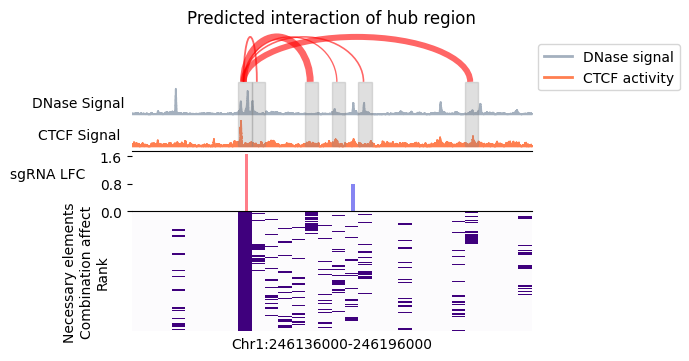

In [12]:
import pickle
import numpy as np
print(-np.log2(0.0309/0.0979))
print(-np.log2(0.0565/0.0979))
print( np.log2(0.0565/0.0979)/np.log2(0.0309/0.0979)*0.8 )
with open('data/fig5/interaction_chr1.pkl','rb') as file:
    data = pickle.load(file)
def norml(x): 
    """
        Min-max normalize x to [0, 1].
    """
    return (x-x.min())/(x.max()-x.min())
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
positions=[i for i in range(246196000-246136000)]
fig = plt.figure(figsize=(4, 3))
ax1 = fig.add_axes([0.0, 0.0, 1.0, 0.4])
sns.heatmap(data[5], ax=ax1, cmap="Purples", cbar=False, linewidths=0, linecolor='#9980FA')
ax1.set_yticks([])
ax1.set_ylabel('Necessary elements\nCombination affect\nRank\n')
ax1.set_xlim([0,30])
ax1.set_xlabel('Chr1:246136000-246196000')
ax1.set_xticks([])
ax3 = fig.add_axes([0.0, 0.4, 1.0, 0.2])
ax3.bar([246137704+15546-246136000,246137704+31510-246136000],[1.663/1.6*0.8,0.7931/1.6*0.8],width=500,color=['#ff4757','#5352ed'],alpha=0.7)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.set_xlim([0,60000]);ax3.set_xticks([])
ax3.set_yticks([0.0,0.4,0.8])
ax3.set_yticklabels(['0.0', '0.8', '1.6'])
ax3.set_ylabel('sgRNA LFC  ',rotation=0,ha='right')
ax2 = fig.add_axes([0.0, 0.6, 1.0, 0.4])
ctcf_array=data[1]
dnase_array=data[2]
y_factor=1.1
ax2.fill_between(positions, 0, norml( ctcf_array )/5, color='#ff7f50',linewidth=1.2)
ax2.fill_between(positions, 0.25, norml( dnase_array )/5+0.25, color='#a4b0be',linewidth=1.2)
connections = [
    ( (80+4)*200, (130+4)*200),
    ( (80+4)*200, (250+4)*200),
    ( (80+4)*200, (90+4)*200),
    ( (80+4)*200, (170+4)*200),
    ( (80+4)*200, (150+4)*200),
]
line_widths = [ 0.497*10, 0.432*10, 0.130*10, 0.117*10, 0.098*10 ]
for idx, (start, end) in enumerate(connections):
    x1, x2 = start, end
    y1, y2 = 0.5, 0.7
    mid = (x1 + x2) / 2
    width = abs(x2 - x1)
    arc = patches.Arc((mid, y1), width=width, height=y2, theta1=0, theta2=180, color='red',
                      alpha=0.6, linewidth=line_widths[idx])
    ax2.add_patch(arc)
for i in [8,13,25,9,17,15]:
    x, y = i*2000, 0
    width, height = 2000, 0.5
    ax   = plt.gca()
    rect = Rectangle((x, y), width, height, linewidth=1, edgecolor='gray', facecolor='gray',alpha=0.25)
    ax.add_patch(rect)
ax2.set_xticks([]);ax2.set_yticks([])
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.set_xlim([0,60000])
ax2.set_title('Predicted interaction of hub region')
ax2.text(-14000,0.05,'CTCF Signal')
ax2.text(-15000,0.30,'DNase Signal')
legend_elements = [
    plt.Line2D([0], [0], color='#a4b0be', lw=2, label='DNase signal'),
    plt.Line2D([0], [0], color='#ff7f50', lw=2, label='CTCF activity')
]
plt.legend(handles=legend_elements, title='',
           bbox_to_anchor=(1.0, 0.95), loc='upper left', ncol=1)
plt.show()


# Figure 5g

In [20]:
import gffutils
def parse_gff(db_path, chrom, start, end):
    """ gffutils  GFF """
    db = gffutils.FeatureDB(db_path)
    genes = []
    for transcript in db.features_of_type('transcript', order_by='start'):
        if transcript.seqid == chrom and transcript.start >= start and transcript.end <= end:
            exons = []
            for exon in db.children(transcript, featuretype='exon', order_by='start'):
                exons.append((exon.start, exon.end))
            genes.append({
                "name": transcript.id,
                "start": transcript.start,
                "end": transcript.end,
                "strand": transcript.strand,
                "exons": exons
            })
    return genes
def draw_genes(ax, genes, startpoint=0, promoter_params=[1000, 0.2, 1000], gene_ylim=[-7.0, -4.5]):
    """ Matplotlib  +  + """
    assert gene_ylim[0] <= gene_ylim[1], "Provide gene_ylim as [lower_val, higher_val]"
    gene_block = [gene_ylim[0], (0.8 * gene_ylim[1]) + (0.2 * gene_ylim[0])]
    prom_height = [gene_block[1], gene_ylim[1]]
    for gene in genes:
        exonStarts = [(start - startpoint) for start, _ in gene["exons"]]
        exonEnds = [(end - startpoint) for _, end in gene["exons"]]
        direction = 1 if gene["strand"] == '+' else -1
        if exonStarts and exonEnds:
            ax.hlines(y=np.mean(gene_block), xmin=min(exonStarts), xmax=max(exonEnds), color='#34ace0')
        for start, end in zip(exonStarts, exonEnds):
            ax.fill_betweenx(gene_block, [start, start], [end, end], facecolor='black')
        x_loc = exonStarts[0] if direction == 1 else exonEnds[-1]
        ax.vlines(x=x_loc, ymin=prom_height[0], ymax=prom_height[1], color='black', linewidth=0.5)
        ax.arrow(x=x_loc, y=prom_height[1], dx=direction * promoter_params[0], dy=0, linewidth=0.5,
                 head_width=promoter_params[1], head_length=promoter_params[2], fc='k', ec='k')
    return None


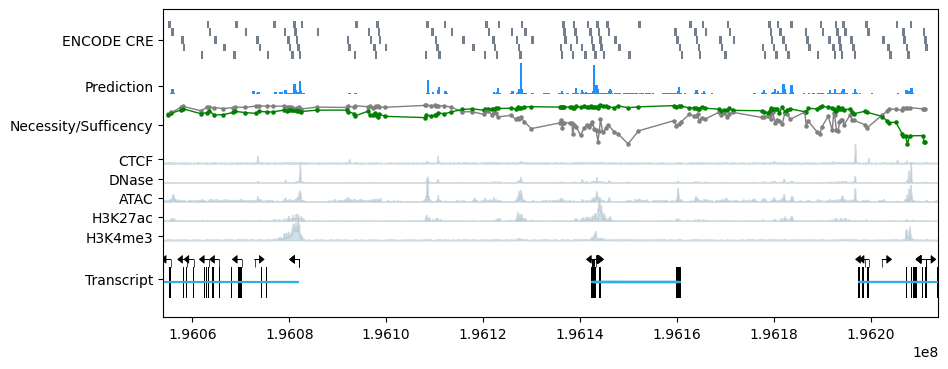

In [22]:
with open('data/fig5/tfrc_data.pkl','rb') as file:
    TFRCLIST,positions,CTCFSIGNAL,DNASESIGNAL,ATACSIGNAL,K27ACSIGNAL,K4ME3SIGNAL,genes,o = pickle.load( file )
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pickle
ATACSIGNAL = np.load('data/fig5/tfrc_epi_ATAC.npy')
CTCFSIGNAL = np.load('data/fig5/tfrc_epi_CTCF.npy')
DNASESIGNAL = np.load('data/fig5/tfrc_epi_DNase.npy')
K27ACSIGNAL = np.load('data/fig5/tfrc_epi_H3K27ac.npy')
K4ME3SIGNAL = np.load('data/fig5/tfrc_epi_H3K4me3.npy')
positions = np.load('data/fig5/tfrc_positions.npy')
with open('data/fig5/tfrc_genes.pkl', 'rb') as f:
    genes = pickle.load(f)
def norm(x):
    """
        Min-max normalize x to [0, 1].
    """
    return (x-x.min())/(x.max()-x.min())
plt.figure(figsize=(10,4))
ax = plt.gca();flag = 0
for info,_ in TFRCLIST.groupby(['start','end','id']):
    s,e,name = info
    rect = patches.Rectangle((s, 2.5-flag*0.2),500,0.2,edgecolor=None,facecolor='#747d8c',alpha = 1.0,linewidth=1.5)
    ax.add_patch(rect)
    if flag==4:flag=0
    else:flag+=1
for i in range(800):
    rect = patches.Rectangle((i*200+196_054_000, 0.8),500,norm(o.numpy().flatten())[i]*0.8,edgecolor=None,facecolor='#1e90ff',alpha = 1.0,linewidth=1.5)
    ax.add_patch(rect)
plt.scatter(TFRCLIST.sort_values(by=['start'])['start'],TFRCLIST.sort_values(by=['start'])['ness']-0.5,color='grey',s=5)
plt.plot(TFRCLIST.sort_values(by=['start'])['start'],TFRCLIST.sort_values(by=['start'])['ness']-0.5,color='grey',linewidth = 1)
plt.scatter(TFRCLIST.sort_values(by=['start'])['start'],TFRCLIST.sort_values(by=['start'])['suff']-0.5,color='green',s=5)
plt.plot(TFRCLIST.sort_values(by=['start'])['start'],TFRCLIST.sort_values(by=['start'])['suff']-0.5,color='green',linewidth = 1)
plt.fill_between(positions, -1.0, CTCFSIGNAL / CTCFSIGNAL.max()/2-1.0, color='#95afc0',alpha=0.4)
plt.fill_between(positions, -1.5, DNASESIGNAL/DNASESIGNAL.max()/2-1.5, color='#95afc0',alpha=0.4)
plt.fill_between(positions, -2.0, ATACSIGNAL / ATACSIGNAL.max()/2-2.0, color='#95afc0',alpha=0.4)
plt.fill_between(positions, -2.5, K27ACSIGNAL/K27ACSIGNAL.max()/2-2.5, color='#95afc0',alpha=0.4)
plt.fill_between(positions, -3.0, K4ME3SIGNAL/K4ME3SIGNAL.max()/2-3.0, color='#95afc0',alpha=0.4)
draw_genes(ax, genes, startpoint=0, gene_ylim=[-4.5,-3.5])
plt.yticks([2.2,1.0,0.0,-0.9,-1.4,-1.9,-2.4,-2.9,-4.0],
           ['ENCODE CRE','Prediction','Necessity/Sufficency','CTCF','DNase','ATAC','H3K27ac','H3K4me3','Transcript'])
plt.xlim([196_054_000,196_214_000]);plt.ylim([-5.0,3.0])
plt.show()


# Figure 5i

In [10]:
TFRCFACS_result = pd.read_csv(
    "data/fig5/tfrc_facs_gene.txt",
    sep='\t'
)
TFRCPro_result  = pd.read_csv(
    "data/fig5/tfrc_prolif_gene.txt",
    sep='\t'
)

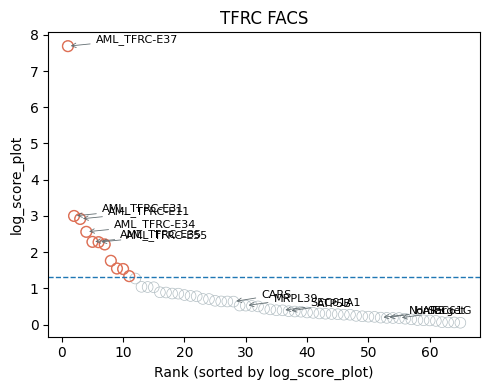

In [14]:
def calc_log_cols(df, score_col, pvalue_col, is_neg):
    """
        Add -log10(score) and -log10(pvalue) columns for ranking/volcano plots.
    
        Args:
            df: input table.
            score_col, pvalue_col: column names.
            is_neg: whether this is the negative selection arm.
    
        Returns:
            A copy of df with log_score and log_pvalue columns.
    """
    df = df.copy()
    df['log_score'] = -np.log10(df[score_col])
    df['log_pvalue'] = -np.log10(df[pvalue_col])
    if is_neg:
        df['log_score_plot'] = df['log_score']
    else:
        df['log_score_plot'] = df['log_score']
    return df
base_neg = calc_log_cols(TFRCFACS_result, "pos|score", "pos|p-value", is_neg=True)
import pandas as pd
import matplotlib.pyplot as plt
df_rank = base_neg.sort_values(
    by='log_score_plot',
    ascending=False
).reset_index(drop=True)
df_rank['rank'] = df_rank.index + 1
threshold = 1.3
num_above_threshold = (df_rank['log_score_plot'] > threshold).sum()
label_ids =['SEC61G','MRPL39','CARS','SEC61A1','ATP5B','HARS','NonTarget']+\
           ['AML_TFRC-E37', 'AML_TFRC-E31','AML_TFRC-E11','AML_TFRC-E34', 'AML_TFRC-E35', 'AML_TFRC-E55']
plt.figure(figsize=(5, 4))
plt.scatter(
    df_rank['rank'],
    df_rank['log_score_plot'],
    facecolors='none',
    edgecolors='#b2bec3',
    s=60,
    linewidths=0.5
)
highlight = df_rank['log_score_plot'] > threshold
plt.scatter(
    df_rank.loc[highlight, 'rank'],
    df_rank.loc[highlight, 'log_score_plot'],
    facecolors='none',
    edgecolors='#e17055',
    s=60,
    linewidths=1
)
plt.axhline(
    y=threshold,
    linestyle='--',
    linewidth=1
)
plt.xlabel('Rank (sorted by log_score_plot)')
plt.ylabel('log_score_plot')
plt.title('TFRC FACS')
df_label = df_rank[df_rank['id'].isin(label_ids)]
for i, (_, row) in enumerate(df_label.iterrows()):
    y_offset = 5
    plt.annotate(
        row['id'],
        xy=(row['rank'], row['log_score_plot']),
        xytext=(20, y_offset),
        textcoords='offset points',
        fontsize=8,
        ha='left',
        va='center' if y_offset > 0 else 'top',
        arrowprops=dict(
            arrowstyle='->',
            linewidth=0.6,
            color='#636e72'
        )
    )
plt.tight_layout()
plt.savefig('figures/TFRCFACS_RRAplot.pdf',dpi=300)
plt.show()


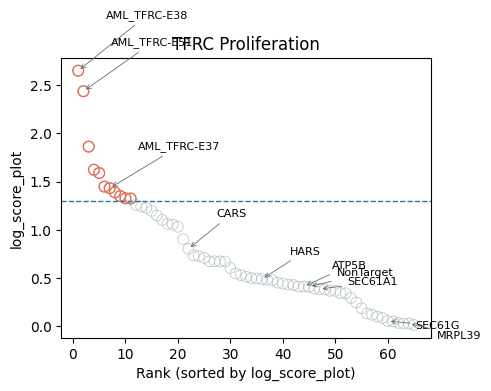

In [13]:
def calc_log_cols(df, score_col, pvalue_col, is_neg):
    """
        Add -log10(score) and -log10(pvalue) columns for ranking/volcano plots.
    
        Args:
            df: input table.
            score_col, pvalue_col: column names.
            is_neg: whether this is the negative selection arm.
    
        Returns:
            A copy of df with log_score and log_pvalue columns.
    """
    df = df.copy()
    df['log_score'] = -np.log10(df[score_col])
    df['log_pvalue'] = -np.log10(df[pvalue_col])
    if is_neg:
        df['log_score_plot'] = df['log_score']
    else:
        df['log_score_plot'] = df['log_score']
    return df
base_neg = calc_log_cols(TFRCPro_result, "neg|score", "neg|p-value", is_neg=True)
import pandas as pd
import matplotlib.pyplot as plt
df_rank = base_neg.sort_values(
    by='log_score_plot',
    ascending=False
).reset_index(drop=True)
df_rank['rank'] = df_rank.index + 1
threshold = 1.3
num_above_threshold = (df_rank['log_score_plot'] > threshold).sum()
label_ids =['SEC61G','MRPL39','CARS','SEC61A1','ATP5B','HARS','NonTarget']+\
           ['AML_TFRC-E38', 'AML_TFRC-E37', 'AML_TFRC-E51']
plt.figure(figsize=(5, 4))
plt.scatter(
    df_rank['rank'],
    df_rank['log_score_plot'],
    facecolors='none',
    edgecolors='#b2bec3',
    s=60,
    linewidths=0.5
)
highlight = df_rank['log_score_plot'] > threshold
plt.scatter(
    df_rank.loc[highlight, 'rank'],
    df_rank.loc[highlight, 'log_score_plot'],
    facecolors='none',
    edgecolors='#e17055',
    s=60,
    linewidths=1
)
plt.axhline(
    y=threshold,
    linestyle='--',
    linewidth=1
)
plt.xlabel('Rank (sorted by log_score_plot)')
plt.ylabel('log_score_plot')
plt.title('TFRC Proliferation')
df_label = df_rank[df_rank['id'].isin(label_ids)]
y_offset = 40
for i, (_, row) in enumerate(df_label.iterrows()):
    plt.annotate(
        row['id'],
        xy=(row['rank'], row['log_score_plot']),
        xytext=(20, y_offset),
        textcoords='offset points',
        fontsize=8,
        ha='left',
        va='center' if y_offset > 0 else 'top',
        arrowprops=dict(
            arrowstyle='->',
            linewidth=0.6,
            color='#636e72'
        )
    )
    if True:
        y_offset -= 5
plt.tight_layout()
plt.savefig('figures/TFRCPro_RRAplot.pdf',dpi=300)
plt.show()
